#HW 4 - Morphology, Edge Detection and Contour Detection (10 pts)
---
For homework assignment HW 4, you will explore morphology, edge detection and contour detection. You can use any advanced functions. However, if you are selected for a random check, you must be able to explain your code.

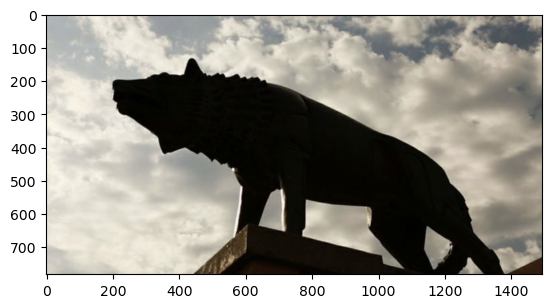

In [1]:
import cv2
import sys
import numpy as np
import matplotlib.pyplot as plt

# cv2_imshow is Colab-only (using matplotlib for display)
# from google.colab.patches import cv2_imshow
# TODO: Test notebook on Colab in case that's what the professor uses.

img_bgr = cv2.imread("Lobo.png")
if img_bgr is None:
	sys.exit("Could not load 'Lobo.png'.")

img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

###Task 1 (3 pts)

Canny edge detection:

1. Smoothing Filter Selection: Canny edge detection is sensitive to noise.You must select the **two best** smoothing filters from our lectures to process Lobo.png image and display the filtered results.

2. Apply Canny edge detection to the filtered images, adjust the thresholds for each to get the cleanest possible boundary of the subject. Display the best result from your experiments.

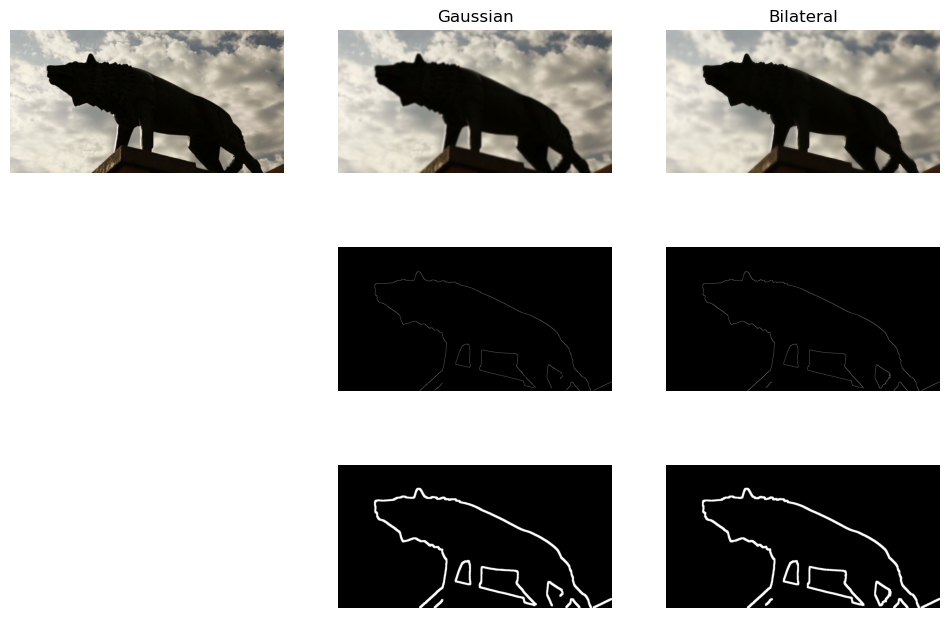

In [ ]:
# 1. Pre-smooth before Canny

sigma = 3.65
gaussian_blur = cv2.GaussianBlur(img, ksize=(0, 0), sigmaX=sigma, sigmaY=sigma)

d, sigmaColor, sigmaSpace = 25, 225, 75
bilateral_blur = cv2.bilateralFilter(img, d, sigmaColor, sigmaSpace)

# 2. Canny edge detection

edges_gauss = cv2.Canny(gaussian_blur, threshold1=50, threshold2=150)
edges_bilat = cv2.Canny(bilateral_blur, threshold1=100, threshold2=200)

# 3. Dilate as edge enhancement (optional)

se = cv2.getStructuringElement(cv2.MORPH_RECT, ksize=(10, 10))
dilated_gauss = cv2.dilate(edges_gauss, se)
dilated_bilat = cv2.dilate(edges_bilat, se)

# 4. Visualize

_, axs = plt.subplots(3, 3, figsize=(12, 8))
axs[0, 0].imshow(img)

axs[0, 1].set_title("Gaussian")
axs[0, 1].imshow(gaussian_blur)
axs[1, 1].imshow(edges_gauss, cmap='gray')
axs[1, 2].imshow(edges_bilat, cmap='gray')

axs[0, 2].set_title("Bilateral")
axs[0, 2].imshow(bilateral_blur)
axs[2, 1].imshow(dilated_gauss, cmap='gray')
axs[2, 2].imshow(dilated_bilat, cmap='gray')

for ax in axs.ravel():
    ax.axis('off')

plt.show()

###Task 2 (7 pts)

Develop a pipeline to separate the UNM Lobo statue from the high-contrast sky and clouds environment:

1. Color pre-processing: evaluate the original image in grayscale and across individual RGB channels. Select and display the single channel (or grayscale version) that provides the maximum contrast between the Lobo statue and the background.

2. Image smoothing: apply the best filter identified in Task 1 (e.g., Box, Median, Gaussian or Bilateral Gaussian, etc.) to the image from step 1. The goal is to suppress cloud noise while preserving the statue's edges.

3. Segmentation: convert the smoothed image into a binary mask using appropriate thresholds.

4. Morphology: apply opening and closing operations to clean the mask.

5. Boundary Detection & Visualization



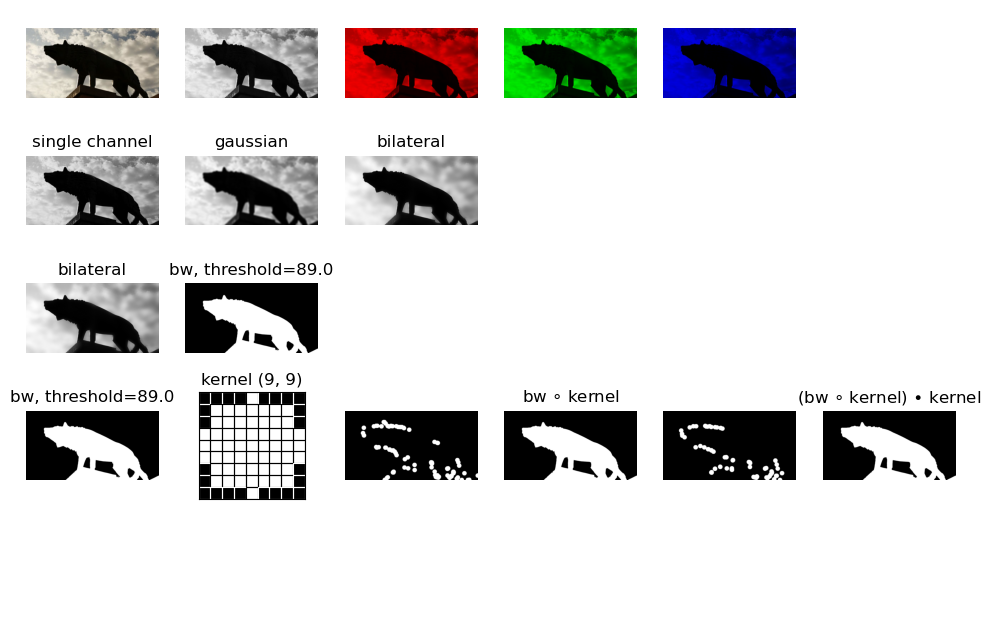

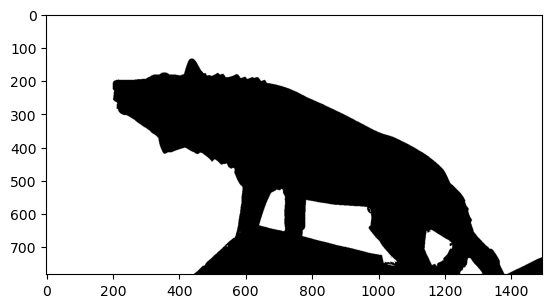

(-0.5, 1493.5, 781.5, -0.5)

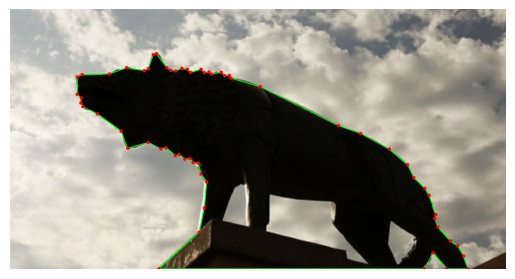

In [3]:
# insert your code

# 1. color pre-processing
grayscale = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

reds = np.zeros_like(img)
reds[..., 0] = img[..., 0]

greens = np.zeros_like(img)
greens[..., 1] = img[..., 1]

blues = np.zeros_like(img)
blues[..., 2] = img[..., 2]

# from unm.dip.morph import otsu    
# colors = {'gray':grayscale, 'red':reds[..., 0], 'green':greens[..., 1], 'blue':blues[..., 2]}
# for name, data in colors.items():
#     _, var = otsu(data)
#     print(name, "=", var.max())


_, axs = plt.subplots(5, 6, figsize=(12, 8))

axs[0, 0].imshow(img)
axs[0, 1].imshow(grayscale, cmap='gray')
axs[0, 2].imshow(reds, cmap='gray')
axs[0, 3].imshow(greens, cmap='gray')
axs[0, 4].imshow(blues, cmap='gray')


# 2. image smoothing
single_channel = blues[..., 2]
gaussian_blur2 = cv2.GaussianBlur(single_channel, ksize=(25, 25), sigmaX=10, sigmaY=10)
bilateral_blur2 = cv2.bilateralFilter(single_channel, d=75, sigmaColor=75, sigmaSpace=75)

axs[1, 0].imshow(single_channel, cmap='gray')
axs[1, 0].set_title("single channel")

axs[1, 1].imshow(gaussian_blur2, cmap='gray')
axs[1, 1].set_title("gaussian")

axs[1, 2].imshow(bilateral_blur2, cmap='gray')
axs[1, 2].set_title("bilateral")


# 3. segmentation + thresholding

# Invert the binary colors: we want the sky to be black and the wolf to be white
otsu_threshold, bw = cv2.threshold(bilateral_blur2, 0, 255, type=cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

axs[2, 0].imshow(bilateral_blur2, cmap='gray')
axs[2, 0].set_title("bilateral")

axs[2, 1].imshow(bw, cmap='gray')
axs[2, 1].set_title(f"bw, threshold={otsu_threshold}")


# 4. morphology
ksize = (9, 9)
shape = cv2.MORPH_ELLIPSE
se = cv2.getStructuringElement(shape=shape, ksize=ksize)
opening = cv2.morphologyEx(bw, op=cv2.MORPH_OPEN, kernel=se)
closing = cv2.morphologyEx(opening, op=cv2.MORPH_CLOSE, kernel=se)
morphed_img = closing.copy()

diff1 = (bw != opening).astype(np.uint8) * 255
diff2 = (opening != closing).astype(np.uint8) * 255

# Dilate difference large enough to see
kernel = cv2.getStructuringElement(shape=shape, ksize=(51, 51))
diff1 = cv2.dilate(diff1, kernel)
diff2 = cv2.dilate(diff2, kernel)

axs[3, 0].imshow(bw, cmap='gray')
axs[3, 0].set_title(f"bw, threshold={otsu_threshold}")

axs[3, 1].imshow(se, cmap='gray')
axs[3, 1].set_title(f"kernel {ksize}")

# Put grid lines around each kernel cell
from matplotlib.patches import Rectangle
for row in range(se.shape[0]):
    for col in range(se.shape[1]):
        color = 'black' if se[row, col] > 0 else 'white'
        axs[3, 1].add_patch(Rectangle((col - 0.5, row - 0.5), 1, 1, fill=False, edgecolor=color, linewidth=0.8))

# Hide tick labels
axs[3, 1].tick_params(axis='both', which='both', length=0, labelbottom=False, labelleft=False)

# axs[3, 1].set_xticks(np.arange(-0.5, 9, 1), minor=True)
# axs[3, 1].set_yticks(np.arange(-0.5, 9, 1), minor=True)

# axs[3, 1].grid(which="minor", color="white", linestyle="-", linewidth=0.8)


axs[3, 2].imshow(diff1, cmap='gray')

axs[3, 3].imshow(opening, cmap='gray')
axs[3, 3].set_title(r"bw $\circ$ kernel")

axs[3, 5].imshow(closing, cmap='gray')
axs[3, 5].set_title(r"(bw $\circ$ kernel) $\bullet$ kernel")

axs[3, 4].imshow(diff2, cmap='gray')


for ax in axs.ravel():
    ax.axis('off')
axs[3, 1].axis('on')
plt.show()

# 5. contour detection
contours, _ = cv2.findContours(morphed_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# contours = False

if not contours:
    sys.exit("No contours found!")


# Draw contour
# Get the largest contour only
largest_contour = max(contours, key=cv2.contourArea)

# contour approximation

# A raw contour is often composed of thousands of points,
# which is computationally expensive and noisy. Contour Approximation
# reduces this complexity by replacing jagged pixel boundaries with a
# simplified polygon of 10 or 20 straight lines.

# Epsilon acts as the error tolerance parameter, it defines the maximum
# deviation allowed between the original curve and the simplified line.
# This allows us to balance spatial precision with computational simplicity.
# cv2.arcLength calculates the total perimeter of the contour

# 0.001 is very fine; change to 0.01 for fewer points in the contour
# 0.001 means that tolerate deviate by 0.1% of the total length.
epsilon = 0.001 * cv2.arcLength(largest_contour, True)  # very fine

# vertices that define the contour
approx_points = cv2.approxPolyDP(largest_contour, epsilon, True)

res = img.copy()

# Draw contour lines
cv2.drawContours(res, [approx_points], -1, (0, 255, 0), 2)

# Draw contour points
for pt in approx_points:
    # cv2.circle(res, (tuple(pt[0])), 3, (0, 0, 255), -1)
    # Red circles
    cv2.circle(res, center=(tuple(pt[0])), radius=5, color=(255, 0, 0), thickness=-1)

plt.imshow(bw, cmap='gray_r')
plt.show()
plt.imshow(res)
plt.axis('off')

6. Extract the Silhouette (choose only one from the following):

* Generate a solid binary mask of the target object. Using your detected
contour, fill the interior region with white pixels on a black background to create a solid silhouette.

* Alternatively, you may use morphological operations to refine the region, provided the resulting shape accurately represents the Lobo statue.

(it is fine if your result is slightly different with the displayed image below. And feel free to come up with your approach to do the work)

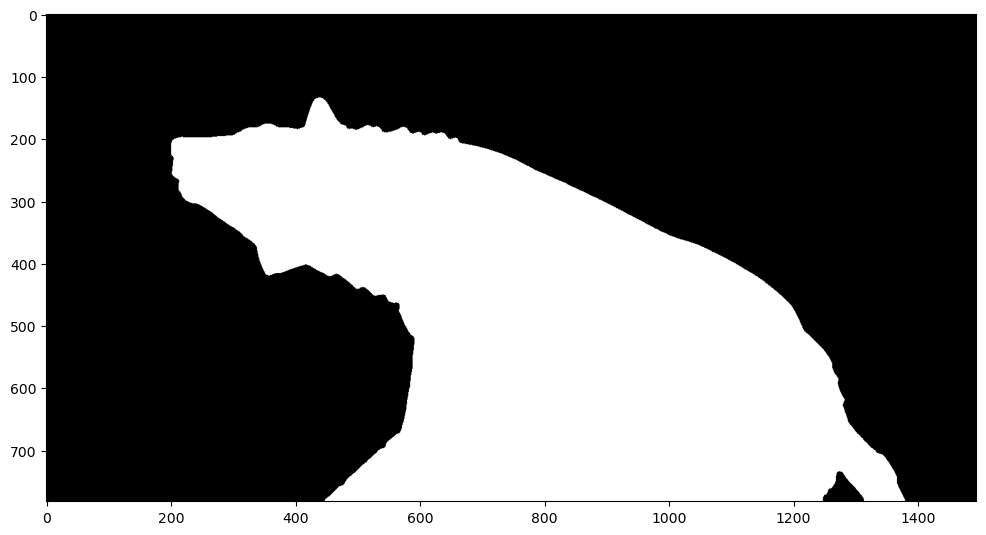

In [11]:
# insert your code
mask = np.zeros_like(bw)
# cv2.drawContours can turn the contour into a solid silhouette
# thickness = -1 fills the contour
largest_cnt = largest_contour.copy()
cv2.drawContours(mask, contours=[largest_cnt], contourIdx=-1, color=255, thickness=-1)
plt.figure(figsize=(12, 8))
plt.imshow(mask, cmap='gray')
plt.show()

7. Get the boundary with morphological gradient

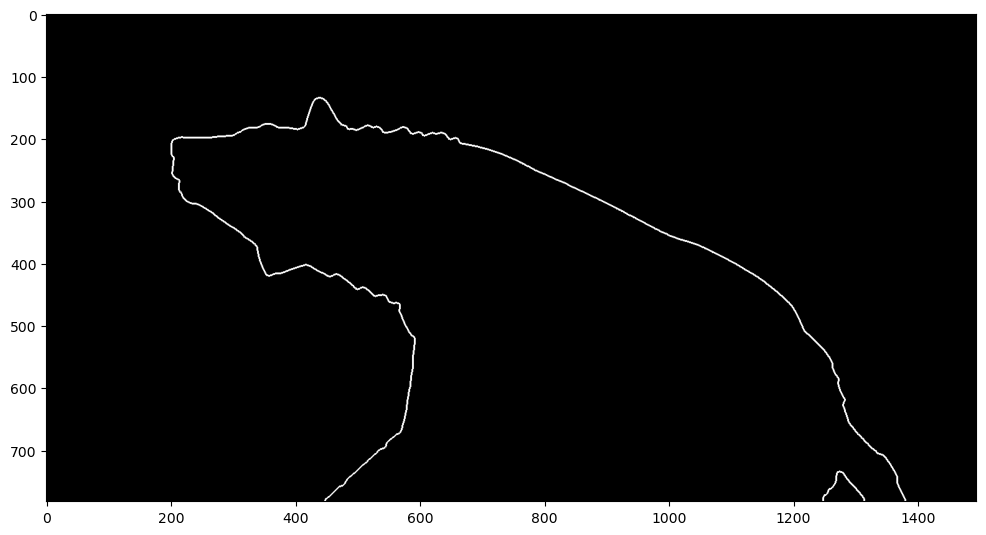

In [ ]:
kernel2 = cv2.getStructuringElement(cv2.MORPH_CROSS, ksize=(4, 4))
boundary = cv2.dilate(mask, kernel2) - cv2.erode(mask, kernel2)     # morphological gradient

plt.figure(figsize=(12, 8))
plt.imshow(boundary, cmap='gray')
plt.show()